# Analysis of Sample OREX-800107-0: Computing the Individual Particle Axes

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import tifffile
from natsort import natsorted 
from scipy.ndimage import label
import skimage
import skimage.measure
from skimage.measure import regionprops
from concurrent.futures import ThreadPoolExecutor, as_completed
from scipy.spatial.distance import pdist, squareform  # only needed for PCA
import csv
from tqdm import tqdm
import pandas as pd

Load in the Dragonfly segmentation:
---------------------------------

In [2]:
# path to the segemented data
folder = 'C:\\Users\\savan\\OREX-800107-0_dragonfly_separated\\OREX-800107-0_dragonfly_separated'

# list all TIFF files and sort them
file_list = natsorted([f for f in os.listdir(folder) if f.endswith('.tiff')])

# read all slices into a list
slices = [(tifffile.imread(os.path.join(folder, fname)) > 0).astype(np.uint8) for fname in file_list]

# stack into a 3D volume (Z, Y, X)
binary_volume = np.stack(slices, axis=0).astype(np.uint8)

print(f"Volume shape for OREX-800107-0: {binary_volume.shape}")

Volume shape for OREX-800107-0: (1720, 1384, 1390)


In [3]:
# apply connected-component labeling (26-connectivity for 3D) 
# previously used 6-connected within dragonfly but the number of particles is consistent between Dragonfly and Jupyter
ParticleLabelCube, num_features = label(binary_volume)
print(f"Number of particles found: {num_features}")

Number of particles found: 30699


In [4]:
# measure multiple properties of labeled objects
props = regionprops(ParticleLabelCube)

Visual Particle Analysis:
-----------------
While attempting to use the PCA (pricipal component analysis) method, some axes were being computed incorrectly in the sense that some of the axes that were computed and assigned to be the longest axes, were smaller than the intermediate axes. Similarly, some of the axes that were computed and assigned to be the intermediate axes, were smaller than the shortest axes. This was due to the fact that the PCA method analyzes the "cloud" of voxels assigned to each individually labeled particle by finding the principal axes and finding the variance of voxels along each of those axes. In theory, this sounds correct but a particle could have a greater variance of voxels parallel to the principal axis, rather than perpendicular (the intended particle axis computation would be represented by the perpendicular voxel variance).

Therefore, these plots show two particles that expressed the above difficulties. These particles were plotted in 3D space in order to visualize the computed axes using the PCA method versus the actual shape of the particle. The particles are plotted using a scatter plot with a colorbar showing the voxel's normalized distance from the centroid. With the results from the PCA method and these plots, it was clear that we needed to use a new method for computing the particle axes.

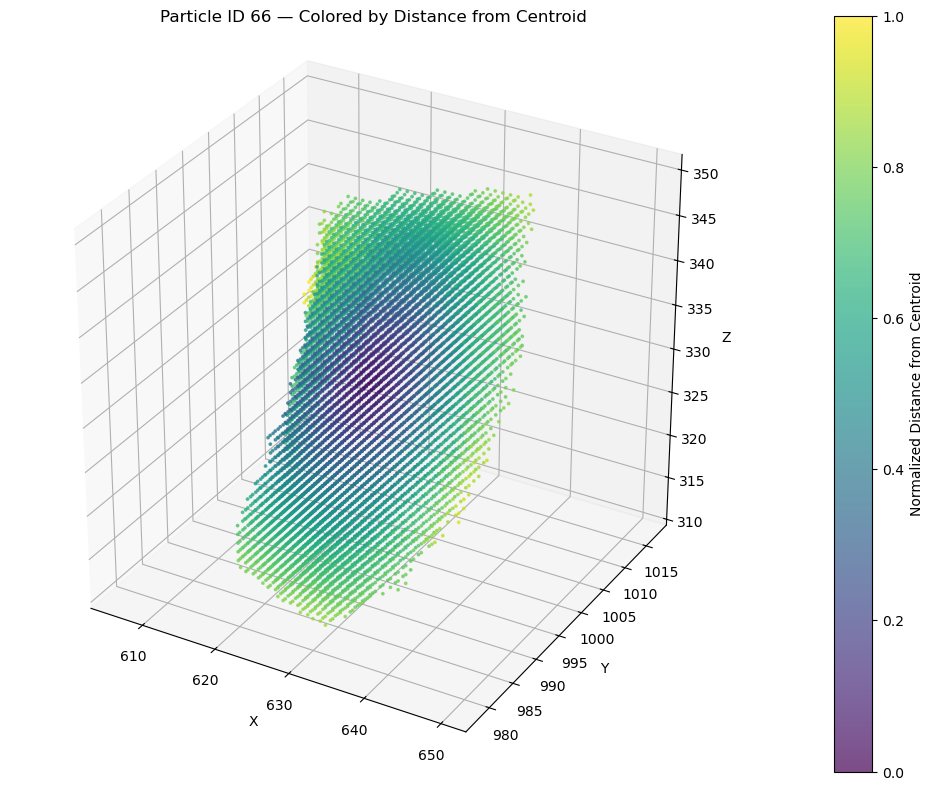

In [5]:
# plot of the first particle where longest < intermediate
particle_id = 66
coords = np.argwhere(ParticleLabelCube == particle_id)

# ensure the particle size is not zero
if coords.size == 0:
    print(f"No voxels found for particle ID {particle_id}")

else:
    # collect coordinates for the particle in each direction
    z, y, x = coords[:, 0], coords[:, 1], coords[:, 2]
    points = np.stack([x, y, z], axis=1)

    # calculate centroid of the particle
    centroid = points.mean(axis=0)

    # calculate Euclidean distance from each point to centroid
    distances = np.linalg.norm(points - centroid, axis=1)

    # normalize distances for color mapping
    norm_distances = (distances - distances.min()) / np.ptp(distances)  # ptp = max - min

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(x, y, z, c=norm_distances, cmap='viridis', s=3, alpha=0.7)

    ax.set_title(f"Particle ID {particle_id} — Colored by Distance from Centroid")
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_box_aspect([1,1,1])

    cb = plt.colorbar(sc, ax=ax, pad=0.1)
    cb.set_label("Normalized Distance from Centroid")

    plt.tight_layout()
    plt.show()

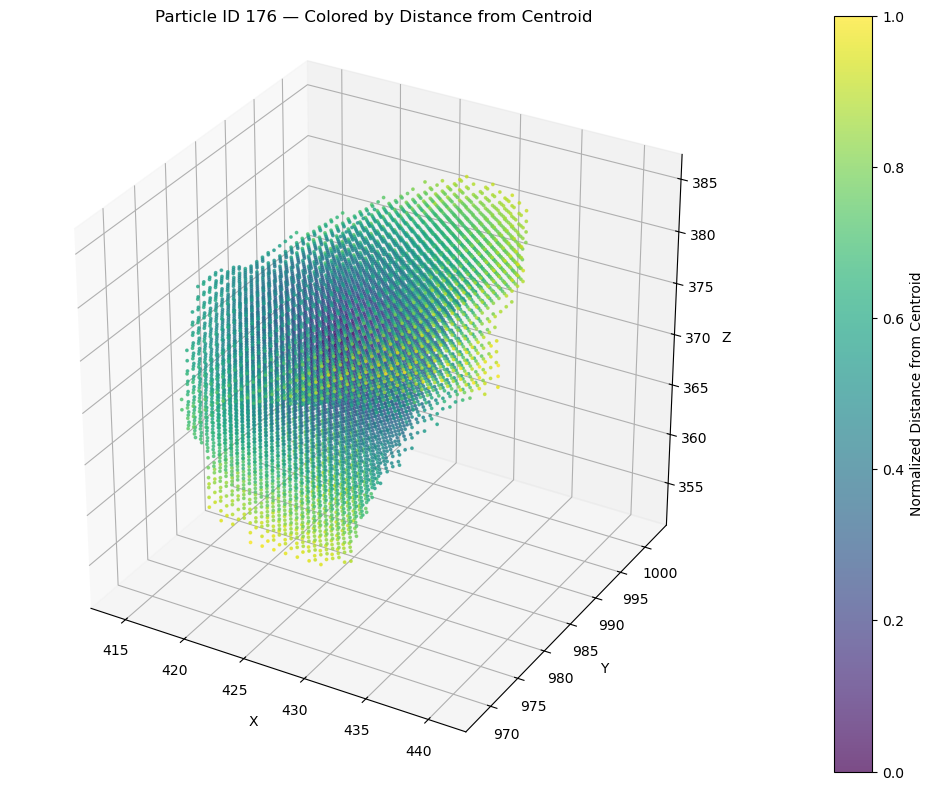

In [6]:
# plot of the second particle where intermediate < short
particle_id = 176
coords = np.argwhere(ParticleLabelCube == particle_id)

# ensure the particle size is not zero
if coords.size == 0:
    print(f"No voxels found for particle ID {particle_id}")
    
else:
    # collect coordinates for the particle in each direction
    z, y, x = coords[:, 0], coords[:, 1], coords[:, 2]
    points = np.stack([x, y, z], axis=1)

    # calculate centroid of the particle
    centroid = points.mean(axis=0)

    # calculate Euclidean distance from each point to centroid
    distances = np.linalg.norm(points - centroid, axis=1)

    # normalize distances for color mapping
    norm_distances = (distances - distances.min()) / np.ptp(distances)  # ptp = max - min

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(x, y, z, c=norm_distances, cmap='viridis', s=3, alpha=0.7)

    ax.set_title(f"Particle ID {particle_id} — Colored by Distance from Centroid")
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_box_aspect([1,1,1])

    cb = plt.colorbar(sc, ax=ax, pad=0.1)
    cb.set_label("Normalized Distance from Centroid")

    plt.tight_layout()
    plt.show()

Computation of Axes:
-------------------
PCA analysis had seemed promising but as seen in the above plots, many of the axes were computed incorrectly (~1000 particles were affected). In lieu of the PCA method, the below code uses an inertia axis method.

Using the inertia tensor method:
-------------------------------
If we generalize each particle as an ellipsoid with semi-axes *a*, *b*, and *c* with mass *M*, we can assume that every voxel is a point mass *m*, contributing to the total mass of the particle (assuming that the particle is uniformly dense). Then we can say that the particle has three different principal moments of inertia about the three different axes:\
$I_a = (1/5) * M (b^2 + c^2)$\
$I_b = (1/5) * M (a^2 + c^2)$\
$I_c = (1/5) * M (a^2 + b^2)$\
where each pricipal moment of inertia is the resistance around the axis aligned with that moment of inertia. In other words, the inertia around one axis depends on the squares of the other two axes.
Since inertia is not a direct measure of axis length, it's important to note that the moments of inertia express the particle's resistance to rotation. This means that a longer axis spreads mass farther from rotation axes which means it has a greater intertia. In the case of the PCA analysis, the variance along a single axis directly relates to its length so it's easier to compute the axis length. When using the inertia tensor, each principal moment of inertia *I* is a combination of two squared axes so the assumption of length $=$ 1/$\sqrt{I}$ is only an approximation.
Therefore, using the above equations for the principal moments of inertia, we can rearrange the equations to solve for the semi-axes *a*, *b*, and *c*:\
$a^2 = (5/(2M)) * (I_b + I_c - I_a)$\
$b^2 = (5/(2M)) * (I_a + I_c - I_b)$\
$c^2 = (5/(2M)) * (I_a + I_b - I_c)$\
In summary, the inertia tensor method uses the fact that inertia about a particular axis measures the spread perpendicular to that axis, resulting in the true axis lengths. In other words, the smallest moment of inertia corresponds to the axis with mass most concentrated near it which is the longest semi-axis. The semi-axes *a*, *b*, and *c* are not necessarily the longest, intermediate, and shortest axes, respectively but hese axes are determined and then sorted in decending order to go into the csv file.

In [10]:
def InertiaAxes(ParticleCoords):
    '''
        This function determines the inertia tensor of the particle and analyzes 
        the mathematical logic for the inertia-based analysis
        
        inputs:
            ParticleCoords: np.ndarray
                the voxel coordinates for an individual particle
                
        outputs:
            axes: list of floats
                the long, intermediate, and short axes of the individual particle
                in voxels
    '''
    
    if ParticleCoords.shape[0] <= 1:
        return [1.0, 1.0, 1.0]  # return default axes

    # center coordinates from the particle's centroid
    centroid = np.mean(ParticleCoords, axis=0)
    rel = ParticleCoords - centroid

    x, y, z = rel[:,0], rel[:,1], rel[:,2]
    m = len(ParticleCoords)  # assume unit mass per voxel

    # define the inertia tensor
    Ixx = np.sum(y**2 + z**2)
    Iyy = np.sum(x**2 + z**2)
    Izz = np.sum(x**2 + y**2)
    Ixy = -np.sum(x * y)
    Ixz = -np.sum(x * z)
    Iyz = -np.sum(y * z)

    I = np.array([[Ixx, Ixy, Ixz],
                  [Ixy, Iyy, Iyz],
                  [Ixz, Iyz, Izz]])

    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(I)
    order = np.argsort(eigvals)  # ascending
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    # compute ellipsoid axes
    # solve for ellipsoid axes from moment of inertia
    # using relations:
    # I1 = (1/5) M (b^2 + c^2)
    # I2 = (1/5) M (a^2 + c^2)
    # I3 = (1/5) M (a^2 + b^2)
    # solve for a, b, and c
    I1, I2, I3 = eigvals
    a2 = np.abs((5.0 / m) * (I2 + I3 - I1) / 2.0)
    b2 = np.abs((5.0 / m) * (I1 + I3 - I2) / 2.0)
    c2 = np.abs((5.0 / m) * (I1 + I2 - I3) / 2.0)

    axes = np.sqrt([a2, b2, c2])
    axes = np.sort(axes)[::-1]  # long > int > short

    return axes.tolist()  # always returns a list of 3 numbers

In [13]:
def ProcessOnePart(prop):
    '''
        This function extracts the particle's voxel coordinates and calls PCAaxes in
        order to return the axes with the particle ID
        
        inputs:
            prop: np.ndarray
                represents one individual particle
                
        outputs:
            ParticleID: int
                the particle's ID
            numeric_axes: tuple
                all three of the particles' axes (short, int, long)
    '''

    # extract the particle ID
    ParticleID = prop.label

    # find the coordinates of the particle
    coords = prop.coords  # (N, 3) voxel coordinates of this particle

    # call InertiaAxes to compute the long, int, and short axes using inertia analysis
    axes = InertiaAxes(coords)

    # flatten and extract the 3 axes to ensure the values can be modified in later code
    flat_axes = np.array(axes, dtype=object).ravel()
    numeric_axes = [float(val) for val in flat_axes if isinstance(val, (int, float, np.number, np.float64, np.int64))]

    # check that there are 3 axes for each particle
    if len(numeric_axes) != 3:
        print(f"Invalid axes for Particle {ParticleID}: {axes}")
        return (ParticleID, None, None, None)

    return (ParticleID, *numeric_axes)  # asterisk unpacks the list so it becomes a tuple

In [32]:
def ComputeAxes_Efficient(ParticleLabelCube, BatchSize, CPUcores, OutputCSV):
    '''
        This function computes the longest, intermediate, and shortest axes of all 
        labeled particles using memory-efficient batching and parallel processing.
        
        inputs:
            ParticleLabelCube: np.ndarray
                3D labeled array of all particles
            BatchSize: int
                number of particles to process per batch
            CPUcores: int
                number of CPU cores to use in parallel
            OutputCSV: str
                path to output CSV file that stores the particle information
            
        outputs:
            ParticleAxes: tuple with shape (NumParticles, 4), with columns:
                        [ParticleID, LongAxis, IntermediateAxis, ShortAxis] in mm
    '''

    # relabel the particle to ensure contiguous labeling
    labels = skimage.measure.label(ParticleLabelCube > 0, connectivity=1)

    # extract particle properties once
    # analyze the labeled regions in the subarray
    # returns a list of objects with thier voxel coordinates and properties
    # prop.label is the particle ID
    # prob.coords is the np array with voxel coords
    props_all = skimage.measure.regionprops(labels)

    # prepare the output CSV with header
    with open(OutputCSV, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["ParticleID", "Long", "Intermediate", "Short"])  # units in mm

    # initialize list to collect axes
    ParticleAxes = []

    # process in batches using thread pool to maximize memory efficiency
    with ThreadPoolExecutor(max_workers=CPUcores) as executor:

        # loops through the particle batches by splitting the array
        # tqdm() adds progress bar
        for i in tqdm(range(0, len(props_all), BatchSize), desc="Processing Batches"):
            batch_props = props_all[i:i+BatchSize]
            
            # submit tasks to the thread pool
            futures = [executor.submit(ProcessOnePart, prop) for prop in batch_props]
            
            # collect results as they complete
            batch_results = [f.result() for f in as_completed(futures)]

            # check the rows of information
            for row in batch_results:
                print(type(row), row)

            # initialize list for results
            batch_results_mm = []
            # organize the values within the tuple
            for row in batch_results:
                ParticleID = row[0]
                axes = row[1:]
            
                # flatten axes to 1D list
                axes = np.array(axes).flatten().tolist()
            
                # convert to mm and apply shrinkage correction
                corrected_axes = [(float(val) * 0.017) + 0.068 for val in axes]
                batch_results_mm.append([ParticleID] + corrected_axes)

            # append results to overall list
            ParticleAxes.extend(batch_results_mm)

            # save results to CSV
            with open(OutputCSV, "a", newline="") as f:
                writer = csv.writer(f)
                writer.writerows(batch_results_mm)

    # sort results by ParticleID and return as NumPy array
    ParticleAxes = np.array(ParticleAxes)
    ParticleAxes = ParticleAxes[np.argsort(ParticleAxes[:, 0])]  # sort by ID

    return ParticleAxes  # already in mm

In [33]:
# computes the axes and puts information into CSV file
ParticleAxesPCA = ComputeAxes_Efficient(ParticleLabelCube, BatchSize=500, CPUcores=2, OutputCSV="ParticleAxes.csv")

Processing Batches:   2%|▏         | 1/62 [00:14<15:11, 14.94s/it]

<class 'tuple'> (1, 65.51138437580178, 48.9064840327778, 42.94889176798887)
<class 'tuple'> (3, 1.0, 1.0, 1.0)
<class 'tuple'> (4, 7.561908229997237, 5.201922766998855, 1.2853726624906232)
<class 'tuple'> (2, 117.10275146160711, 91.90358794550689, 78.79150565691916)
<class 'tuple'> (6, 66.28743693481012, 57.420652528168745, 41.72920730758527)
<class 'tuple'> (5, 159.15887042798244, 96.05790110004916, 42.39657575489129)
<class 'tuple'> (8, 3.1622776601683795, 0.0, 0.0)
<class 'tuple'> (9, 62.78952137643122, 38.00659243983886, 23.681133601253908)
<class 'tuple'> (10, 5.123475382979799, 0.0, 0.0)
<class 'tuple'> (11, 1.118033988749895, 1.118033988749895, 0.0)
<class 'tuple'> (12, 59.86513563706721, 51.6639961077181, 34.644270758720396)
<class 'tuple'> (13, 1.118033988749895, 0.0, 0.0)
<class 'tuple'> (14, 8.572985578284365, 6.240007310686418, 0.7573051671503518)
<class 'tuple'> (7, 165.13046038249504, 88.75312005889394, 75.88589988060475)
<class 'tuple'> (15, 82.99984031536229, 65.6923481

Processing Batches:   3%|▎         | 2/62 [00:23<11:20, 11.34s/it]

<class 'tuple'> (502, 15.75475985733714, 10.698745072158559, 8.242786316338554)
<class 'tuple'> (503, 29.805047481994542, 25.406725872782875, 14.400038327530204)
<class 'tuple'> (504, 13.530019327008109, 10.564125995209965, 6.991113633735796)
<class 'tuple'> (505, 8.665210134435391, 4.867637541503101, 2.9937635456771594)
<class 'tuple'> (506, 10.868180532927262, 9.250203903406213, 5.575037268497926)
<class 'tuple'> (507, 12.710080431768247, 7.820832794818646, 5.652300529240825)
<class 'tuple'> (508, 10.335087451456115, 9.65573694465723, 6.782400962842515)
<class 'tuple'> (509, 10.881068637633328, 5.939173700772517, 2.0529120060472)
<class 'tuple'> (501, 35.964838304369366, 25.27559766725005, 17.465418572356782)
<class 'tuple'> (511, 65.24105042982728, 51.52106849098269, 14.260277236056877)
<class 'tuple'> (512, 7.354072598951704, 4.010885239136313, 2.5526034291194395)
<class 'tuple'> (513, 7.234960763728769, 3.076304925402139, 1.5114031171918532)
<class 'tuple'> (514, 34.46505756448884

Processing Batches:   5%|▍         | 3/62 [00:28<08:00,  8.14s/it]

...

<class 'tuple'> (29001, 16.447176037310175, 3.792318789079097, 2.755022117670461)
<class 'tuple'> (29002, 8.700365000077843, 8.044131579149909, 4.495772685067776)
<class 'tuple'> (29003, 8.722356357226104, 4.467927064221114, 3.593567519247938)
<class 'tuple'> (29005, 8.040034879114552, 3.7883357759444527, 1.4289937290988801)
<class 'tuple'> (29006, 8.020319438587812, 2.827583921856836, 1.633621422508208)
<class 'tuple'> (29007, 7.5670439404299925, 4.494155952520756, 3.344397828110434)
<class 'tuple'> (29004, 27.324097002536394, 19.125209448570512, 15.64523487534546)
<class 'tuple'> (29009, 11.207144008054756, 9.313949384324976, 4.466461084072111)
<class 'tuple'> (29010, 7.9683300963464445, 3.874706278236856, 2.2438464147644703)
<class 'tuple'> (29011, 6.749324309312913, 4.288565578697188, 3.845198912291037)
<class 'tuple'> (29012, 8.984867584491353, 7.976799033145715, 5.354061594149283)
<class 'tuple'> (29013, 27.020751718168473, 17.58671912492903, 12.610788236287856)
<class 'tuple'> (

Processing Batches:  97%|█████████▋| 60/62 [02:07<00:01,  1.17it/s]

<class 'tuple'> (29502, 24.35106688647056, 13.144809864078972, 6.562814929794072)
<class 'tuple'> (29503, 6.708380971747028, 3.185116793158415, 2.289881970305597)
<class 'tuple'> (29504, 7.43969486136125, 4.378686715293245, 3.2495801719025414)
<class 'tuple'> (29501, 28.713788972335642, 12.43312928067039, 9.479010533079798)
<class 'tuple'> (29506, 16.90696429471588, 11.77409309853021, 3.082083653166707)
<class 'tuple'> (29507, 3.8097231983151794, 3.73673367453554, 2.733908373589288)
<class 'tuple'> (29505, 20.416917946365416, 15.325574575241735, 7.106609574898767)
<class 'tuple'> (29509, 5.621755283595547, 3.9672600763721757, 1.228914055993341)
<class 'tuple'> (29510, 6.199587407927566, 5.1138565436945544, 2.670934080523514)
<class 'tuple'> (29508, 8.65794395064873, 7.025125384769185, 2.803550166886289)
<class 'tuple'> (29511, 12.381155102215036, 5.564791389300514, 3.6975628978695294)
<class 'tuple'> (29512, 7.12313450498893, 5.769366658056438, 2.922574240607845)
<class 'tuple'> (29514

Processing Batches: 100%|██████████| 62/62 [02:08<00:00,  2.07s/it]

<class 'tuple'> (30001, 11.907107917409688, 6.076038074312764, 5.726938329649121)
<class 'tuple'> (30002, 5.839973259252768, 3.355438843885419, 1.9984115151279418)
<class 'tuple'> (30004, 4.988564769697585, 4.032481061659153, 1.607578850765816)
<class 'tuple'> (30003, 21.78089585849046, 9.142769706248993, 8.648834817282026)
<class 'tuple'> (30006, 12.977586676808835, 4.267484381342641, 2.738126878576976)
<class 'tuple'> (30007, 8.700393372953679, 8.148392815787895, 4.938539824908094)
<class 'tuple'> (30008, 21.6749381003365, 14.371152937355697, 10.589330469351793)
<class 'tuple'> (30009, 7.557171323837689, 3.7745424503962046, 2.142010106872086)
<class 'tuple'> (30005, 34.21062165921322, 23.155533860909404, 17.798009134771306)
<class 'tuple'> (30011, 13.321037469214966, 8.389277857598117, 7.531864197740642)
<class 'tuple'> (30010, 28.51737110136478, 26.485753454274455, 17.002943999040312)
<class 'tuple'> (30013, 6.501795220366581, 3.9079069089643275, 2.447853886108847)
<class 'tuple'> (